Loading from: ['/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt']
Loaded #models (experiments): 3  | each has shape like: (35, 512)


/tmp/ipykernel_2500279/2790343757.py:522: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


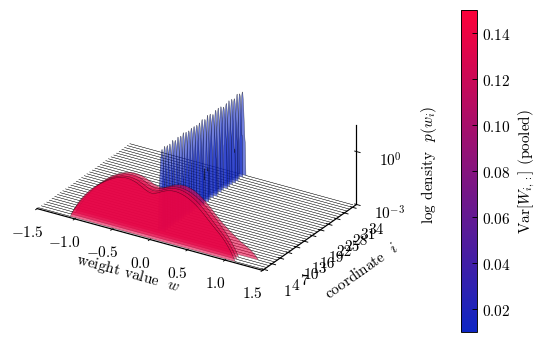

In [3]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look)
import os, sys, glob, math, time, json, random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Any

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------

def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------

def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")


def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers (UPDATED to read particles saved by your training code)
# -----------------------------------------------------------------------------

def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]


def _load_W_list_from_particles_pt(pt_path: str, map_location="cpu") -> List[torch.Tensor]:
    """
    Load a particles snapshot saved by your training code's _save_particles().
    Returns a list of tensors [W_e^T] with shape (d, B) for each experiment e.
    Accepts either:
      pkg = {"params":{"W": (E,B,d), "a":..., "rho":...}, "stats":..., "meta":...}
    or a flat dict with "W".
    """
    pkg = torch.load(pt_path, map_location=map_location)
    if isinstance(pkg, dict) and "params" in pkg and isinstance(pkg["params"], dict) and "W" in pkg["params"]:
        W_EBD = pkg["params"]["W"]
    elif isinstance(pkg, dict) and "W" in pkg:
        W_EBD = pkg["W"]
    else:
        raise KeyError(f"{pt_path}: expected 'params[\"W\"]' or top-level 'W' in snapshot.")
    if W_EBD.ndim != 3:
        raise ValueError(f"{pt_path}: expected W shape (E,B,d), got {tuple(W_EBD.shape)}")
    E, B, d = W_EBD.shape
    # Convert per-experiment to shape (d, B) to match downstream plotting code
    return [W_EBD[e].detach().cpu().T.contiguous() for e in range(E)]


def _load_W_list_from_particles_npz(npz_path: str) -> List[torch.Tensor]:
    """
    Load the compressed NumPy snapshot saved alongside the .pt by _save_particles().
    """
    z = np.load(npz_path)
    if "W" not in z:
        raise KeyError(f"{npz_path}: missing 'W' array.")
    W = z["W"]  # (E,B,d)
    if W.ndim != 3:
        raise ValueError(f"{npz_path}: expected W shape (E,B,d), got {W.shape}")
    E, B, d = W.shape
    return [torch.from_numpy(W[e].T.copy()) for e in range(E)]  # (d,B)


def _resolve_snapshot_from_json(json_path: str) -> Optional[str]:
    """
    Given a training JSON (the big log file), pick the 'final' particles snapshot path if present,
    otherwise fall back to 'init'. Prefer the .pt snapshot; if missing, try the .npz.
    """
    with open(json_path, "r") as f:
        payload = json.load(f)
    snaps = payload.get("snapshots", {})
    final = snaps.get("final", {})
    init = snaps.get("init", {})
    for bucket in (final, init):
        if isinstance(bucket, dict):
            if bucket.get("pt"):
                return bucket["pt"]
            if bucket.get("npz"):
                return bucket["npz"]
    return None


def load_W_list_from_paths(paths: List[str], map_location="cpu") -> List[torch.Tensor]:
    """
    Accepts a list of paths where each path can be:
      - a particles .pt (preferred)   -> loads (E,B,d) and splits into E items
      - a particles .npz              -> loads (E,B,d) and splits into E items
      - a training .json log          -> resolves to snapshots.final/init and loads
    Returns a flat list of W matrices with shape (d, N_i) each (N_i = B per exp).
    """
    out: List[torch.Tensor] = []
    for p in paths:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Path not found: {p}")
        ext = os.path.splitext(p)[1].lower()
        resolved = p
        if ext == ".json":
            resolved = _resolve_snapshot_from_json(p)
            if resolved is None:
                raise FileNotFoundError(f"{p}: could not find snapshot paths in JSON.")
            ext = os.path.splitext(resolved)[1].lower()
        if ext == ".pt":
            out.extend(_load_W_list_from_particles_pt(resolved, map_location=map_location))
        elif ext == ".npz":
            out.extend(_load_W_list_from_particles_npz(resolved))
        else:
            raise ValueError(f"Unsupported file extension for {p}. Use .pt, .npz, or .json.")
    # sanity: all must share the same d
    if not out:
        raise ValueError("No weights loaded.")
    d_ref = out[0].shape[0]
    for i, W in enumerate(out):
        if W.ndim != 2 or W.shape[0] != d_ref:
            raise ValueError(f"All W must be 2D with same d. Item {i} has shape {tuple(W.shape)} vs d={d_ref}.")
    return out  # [ (d x B_e) for each experiment e across all provided paths ]

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------

def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^	op$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 6.4),
):
    """Average Gram (WW^T) across models and draw a boxed heatmap.

    New: pass `figsize=(width, height)` to control figure size.
    """
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------

def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: list like ['#0066ff', '#ff3366'] or with a middle ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        # Default to original palette idea (blue → purple → red) via slim_plotters
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens


def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="plots/_pw_avg.svg",
    # New knobs for making it FLATTER
    figsize=(10.5, 6.2),     # figure size (w, h)
    z_scale=1.0,             # compress vertical scale: e.g. 0.3 for much flatter
    box_aspect=None,         # e.g. (1, 1, 0.25) to squash z vs x/y
    ortho=True,              # use orthographic projection to reduce perspective
    # New: explicit log tick exponents (unscaled). Example: (0,3) -> show 10^0 and 10^3
    z_log_ticks=None,
):
    """3D ridgeline of average per-row densities across models.

    To make the plot flatter:
      - Lower `z_scale` (try 0.2–0.5).
      - Pass a smaller height in `figsize` (e.g., (10.5, 3.6)).
      - Set `box_aspect=(1, 1, 0.25)` (requires Matplotlib ≥3.3).
      - Reduce `y_step` to squeeze rows closer together.
      - Keep `ortho=True` to reduce perspective exaggeration.

    Ticks:
      - If `z_log=True` and `z_log_ticks` is provided (e.g., `(0, 3)`), the Z axis
        will only show those powers of 10.
    """
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- vertical compression (NEW) ----------
    z_scale = float(z_scale) if np.isfinite(z_scale) else 1.0
    dens_plot_scaled = base_z + (dens_plot - base_z) * z_scale

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot_scaled, v in zip(dens_plot_scaled, variances):
        poly = list(zip(grid, di_plot_scaled)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')

    # Orthographic projection reduces perspective exaggeration (flatter look)
    try:
        ax.set_proj_type('ortho' if ortho else 'persp')
    except Exception:
        pass

    ys = np.arange(len(rows)) * y_step
    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot_scaled)) if dens_plot_scaled.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        if z_log_ticks is not None and len(z_log_ticks) > 0:
            # Map requested exponents (unscaled) to scaled Z positions
            tick_positions = [base_z + (float(E) - base_z) * max(z_scale, 1e-12) for E in z_log_ticks]
            ax.set_zticks(tick_positions)
            ax.set_zticklabels([rf"$10^{{{int(E)}}}$" for E in z_log_ticks])
        else:
            # Default: integer ticks with formatter that accounts for scaling
            ax.zaxis.set_major_locator(MaxNLocator(integer=True))
            def _log_tick_formatter(v, pos):
                inv = base_z + (v - base_z) / max(z_scale, 1e-12)  # inverse of scaling
                return rf"$10^{{{int(round(inv))}}}$"
            ax.zaxis.set_major_formatter(FuncFormatter(_log_tick_formatter))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    # Optional: force a flatter 3D box aspect (requires Matplotlib ≥ 3.3)
    if box_aspect is not None:
        try:
            ax.set_box_aspect(box_aspect)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide one or more paths to your saved runs. Each path can be:
#   - the training JSON (we'll auto-resolve to snapshots.final/init),
#   - a '__final_particles.pt' (preferred), or
#   - a '__final_particles.npz' (also ok).
SNAPSHOT_FILES = [
  #"/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_3_fix/5e-3/rs_aw_ard_sgld_FAST_P2133_kap5.000e-03_Ptr2133_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
  "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
  ]

if not SNAPSHOT_FILES:
    # fallback: grab newest snapshot .pt/.npz/.json from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "*__final_particles.pt"))
        + glob.glob(os.path.join(MODEL_DIR, "*__final_particles.npz"))
        + glob.glob(os.path.join(MODEL_DIR, "rs_aw_*.json")),
        key=os.path.getmtime
    )
    SNAPSHOT_FILES = all_candidates[-1:]  # last one by default

print("Loading from:", SNAPSHOT_FILES)
W_list = load_W_list_from_paths(SNAPSHOT_FILES, map_location="cpu")
print("Loaded #models (experiments):", len(W_list), " | each has shape like:", tuple(W_list[0].shape))

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.01
HEAT_VMAX = 0.15

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.15

# 1) Average WW^T heatmap across models (now with figsize)


# 2) Multi-model ridgeline: average p(w_i) across models (E experiments)
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-1.5, 1.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,            # or e.g. weights ∝ N_i
    y_step=0.65,                   # << rows closer together
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pw_ard.svg",
    # NEW knobs to make it *much flatter*:
    figsize=(10.5, 3.8),   # << shorter figure height
    z_scale=0.30,          # << compress vertical scale strongly
    box_aspect=(1.5, 1, 0.5),  # << squash z relative to x/y
    ortho=True,
    # NEW: only show two Z ticks at 10^0 and 10^3
    z_log_ticks=(-3, 0),
)


Loading from: ['/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt']
Loaded #models (experiments): 3  | each has shape like: (35, 512)


/tmp/ipykernel_1261651/3349109418.py:522: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


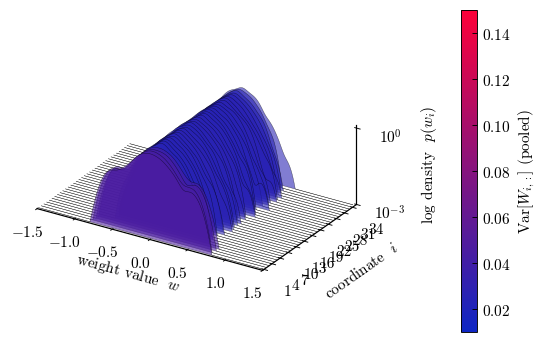

In [19]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look)
import os, sys, glob, math, time, json, random
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Any

import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------

def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------

def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")


def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers (UPDATED to read particles saved by your training code)
# -----------------------------------------------------------------------------

def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]


def _load_W_list_from_particles_pt(pt_path: str, map_location="cpu") -> List[torch.Tensor]:
    """
    Load a particles snapshot saved by your training code's _save_particles().
    Returns a list of tensors [W_e^T] with shape (d, B) for each experiment e.
    Accepts either:
      pkg = {"params":{"W": (E,B,d), "a":..., "rho":...}, "stats":..., "meta":...}
    or a flat dict with "W".
    """
    pkg = torch.load(pt_path, map_location=map_location)
    if isinstance(pkg, dict) and "params" in pkg and isinstance(pkg["params"], dict) and "W" in pkg["params"]:
        W_EBD = pkg["params"]["W"]
    elif isinstance(pkg, dict) and "W" in pkg:
        W_EBD = pkg["W"]
    else:
        raise KeyError(f"{pt_path}: expected 'params[\"W\"]' or top-level 'W' in snapshot.")
    if W_EBD.ndim != 3:
        raise ValueError(f"{pt_path}: expected W shape (E,B,d), got {tuple(W_EBD.shape)}")
    E, B, d = W_EBD.shape
    # Convert per-experiment to shape (d, B) to match downstream plotting code
    return [W_EBD[e].detach().cpu().T.contiguous() for e in range(E)]


def _load_W_list_from_particles_npz(npz_path: str) -> List[torch.Tensor]:
    """
    Load the compressed NumPy snapshot saved alongside the .pt by _save_particles().
    """
    z = np.load(npz_path)
    if "W" not in z:
        raise KeyError(f"{npz_path}: missing 'W' array.")
    W = z["W"]  # (E,B,d)
    if W.ndim != 3:
        raise ValueError(f"{npz_path}: expected W shape (E,B,d), got {W.shape}")
    E, B, d = W.shape
    return [torch.from_numpy(W[e].T.copy()) for e in range(E)]  # (d,B)


def _resolve_snapshot_from_json(json_path: str) -> Optional[str]:
    """
    Given a training JSON (the big log file), pick the 'final' particles snapshot path if present,
    otherwise fall back to 'init'. Prefer the .pt snapshot; if missing, try the .npz.
    """
    with open(json_path, "r") as f:
        payload = json.load(f)
    snaps = payload.get("snapshots", {})
    final = snaps.get("final", {})
    init = snaps.get("init", {})
    for bucket in (final, init):
        if isinstance(bucket, dict):
            if bucket.get("pt"):
                return bucket["pt"]
            if bucket.get("npz"):
                return bucket["npz"]
    return None


def load_W_list_from_paths(paths: List[str], map_location="cpu") -> List[torch.Tensor]:
    """
    Accepts a list of paths where each path can be:
      - a particles .pt (preferred)   -> loads (E,B,d) and splits into E items
      - a particles .npz              -> loads (E,B,d) and splits into E items
      - a training .json log          -> resolves to snapshots.final/init and loads
    Returns a flat list of W matrices with shape (d, N_i) each (N_i = B per exp).
    """
    out: List[torch.Tensor] = []
    for p in paths:
        if not os.path.exists(p):
            raise FileNotFoundError(f"Path not found: {p}")
        ext = os.path.splitext(p)[1].lower()
        resolved = p
        if ext == ".json":
            resolved = _resolve_snapshot_from_json(p)
            if resolved is None:
                raise FileNotFoundError(f"{p}: could not find snapshot paths in JSON.")
            ext = os.path.splitext(resolved)[1].lower()
        if ext == ".pt":
            out.extend(_load_W_list_from_particles_pt(resolved, map_location=map_location))
        elif ext == ".npz":
            out.extend(_load_W_list_from_particles_npz(resolved))
        else:
            raise ValueError(f"Unsupported file extension for {p}. Use .pt, .npz, or .json.")
    # sanity: all must share the same d
    if not out:
        raise ValueError("No weights loaded.")
    d_ref = out[0].shape[0]
    for i, W in enumerate(out):
        if W.ndim != 2 or W.shape[0] != d_ref:
            raise ValueError(f"All W must be 2D with same d. Item {i} has shape {tuple(W.shape)} vs d={d_ref}.")
    return out  # [ (d x B_e) for each experiment e across all provided paths ]

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------

def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^	op$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 6.4),
):
    """Average Gram (WW^T) across models and draw a boxed heatmap.

    New: pass `figsize=(width, height)` to control figure size.
    """
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------

def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: list like ['#0066ff', '#ff3366'] or with a middle ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        # Default to original palette idea (blue → purple → red) via slim_plotters
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens


def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="plots/_pw_avg.svg",
    # New knobs for making it FLATTER
    figsize=(10.5, 6.2),     # figure size (w, h)
    z_scale=1.0,             # compress vertical scale: e.g. 0.3 for much flatter
    box_aspect=None,         # e.g. (1, 1, 0.25) to squash z vs x/y
    ortho=True,              # use orthographic projection to reduce perspective
    # New: explicit log tick exponents (unscaled). Example: (0,3) -> show 10^0 and 10^3
    z_log_ticks=None,
):
    """3D ridgeline of average per-row densities across models.

    To make the plot flatter:
      - Lower `z_scale` (try 0.2–0.5).
      - Pass a smaller height in `figsize` (e.g., (10.5, 3.6)).
      - Set `box_aspect=(1, 1, 0.25)` (requires Matplotlib ≥3.3).
      - Reduce `y_step` to squeeze rows closer together.
      - Keep `ortho=True` to reduce perspective exaggeration.

    Ticks:
      - If `z_log=True` and `z_log_ticks` is provided (e.g., `(0, 3)`), the Z axis
        will only show those powers of 10.
    """
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- vertical compression (NEW) ----------
    z_scale = float(z_scale) if np.isfinite(z_scale) else 1.0
    dens_plot_scaled = base_z + (dens_plot - base_z) * z_scale

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot_scaled, v in zip(dens_plot_scaled, variances):
        poly = list(zip(grid, di_plot_scaled)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')

    # Orthographic projection reduces perspective exaggeration (flatter look)
    try:
        ax.set_proj_type('ortho' if ortho else 'persp')
    except Exception:
        pass

    ys = np.arange(len(rows)) * y_step
    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot_scaled)) if dens_plot_scaled.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        if z_log_ticks is not None and len(z_log_ticks) > 0:
            # Map requested exponents (unscaled) to scaled Z positions
            tick_positions = [base_z + (float(E) - base_z) * max(z_scale, 1e-12) for E in z_log_ticks]
            ax.set_zticks(tick_positions)
            ax.set_zticklabels([rf"$10^{{{int(E)}}}$" for E in z_log_ticks])
        else:
            # Default: integer ticks with formatter that accounts for scaling
            ax.zaxis.set_major_locator(MaxNLocator(integer=True))
            def _log_tick_formatter(v, pos):
                inv = base_z + (v - base_z) / max(z_scale, 1e-12)  # inverse of scaling
                return rf"$10^{{{int(round(inv))}}}$"
            ax.zaxis.set_major_formatter(FuncFormatter(_log_tick_formatter))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    # Optional: force a flatter 3D box aspect (requires Matplotlib ≥ 3.3)
    if box_aspect is not None:
        try:
            ax.set_box_aspect(box_aspect)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide one or more paths to your saved runs. Each path can be:
#   - the training JSON (we'll auto-resolve to snapshots.final/init),
#   - a '__final_particles.pt' (preferred), or
#   - a '__final_particles.npz' (also ok).
SNAPSHOT_FILES = [
  #"/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_3_fix/5e-3/rs_aw_ard_sgld_FAST_P2133_kap5.000e-03_Ptr2133_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
"/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"
  ]

if not SNAPSHOT_FILES:
    # fallback: grab newest snapshot .pt/.npz/.json from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "*__final_particles.pt"))
        + glob.glob(os.path.join(MODEL_DIR, "*__final_particles.npz"))
        + glob.glob(os.path.join(MODEL_DIR, "rs_aw_*.json")),
        key=os.path.getmtime
    )
    SNAPSHOT_FILES = all_candidates[-1:]  # last one by default

print("Loading from:", SNAPSHOT_FILES)
W_list = load_W_list_from_paths(SNAPSHOT_FILES, map_location="cpu")
print("Loaded #models (experiments):", len(W_list), " | each has shape like:", tuple(W_list[0].shape))

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.01
HEAT_VMAX = 0.15

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.15

# 1) Average WW^T heatmap across models (now with figsize)


# 2) Multi-model ridgeline: average p(w_i) across models (E experiments)
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-1.5, 1.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,            # or e.g. weights ∝ N_i
    y_step=0.65,                   # << rows closer together
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pw_noard.svg",
    # NEW knobs to make it *much flatter*:
    figsize=(10.5, 3.8),   # << shorter figure height
    z_scale=0.30,          # << compress vertical scale strongly
    box_aspect=(1.5, 1, 0.5),  # << squash z relative to x/y
    ortho=True,
    # NEW: only show two Z ticks at 10^0 and 10^3
    z_log_ticks=(-3, 0),
)


Loading N models: 3


/tmp/ipykernel_1261651/2650632748.py:436: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


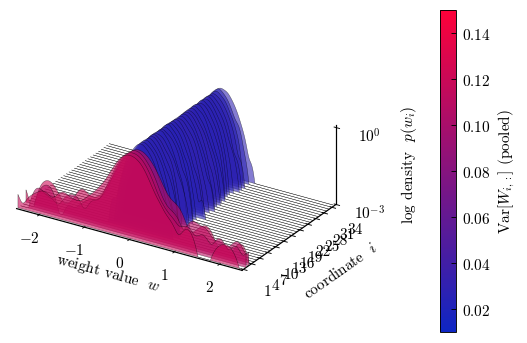

In [21]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look)
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------

def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------

def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")


def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------

def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]


def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a


def load_many_W(model_paths, map_location="cpu"):
    """Return list of W tensors (each d x N_i). All must share same d."""
    W_list = []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if W.ndim != 2:
            raise ValueError(f"{p}: expected W to be 2D, got {tuple(W.shape)}")
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(
                f"All models must share the same number of rows d. "
                f"Got {d_ref} and {W.shape[0]} for {p}."
            )
        W_list.append(W.detach().cpu())
    return W_list  # [d x N_i], same d, variable N_i okay

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------

def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^	op$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 6.4),
):
    """Average Gram (WW^T) across models and draw a boxed heatmap.

    New: pass `figsize=(width, height)` to control figure size.
    """
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------

def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pw_NN.svg",
    # New knobs for making it FLATTER
    figsize=(10.5, 6.2),     # figure size (w, h)
    z_scale=1.0,             # compress vertical scale: e.g. 0.3 for much flatter
    box_aspect=None,         # e.g. (1, 1, 0.25) to squash z vs x/y
    ortho=True,              # use orthographic projection to reduce perspective
    # New: explicit log tick exponents (unscaled). Example: (0,3) -> show 10^0 and 10^3
    z_log_ticks=None,
):
    """3D ridgeline of average per-row densities across models.

    To make the plot flatter:
      - Lower `z_scale` (try 0.2–0.5).
      - Pass a smaller height in `figsize` (e.g., (10.5, 3.6)).
      - Set `box_aspect=(1, 1, 0.25)` (requires Matplotlib ≥3.3).
      - Reduce `y_step` to squeeze rows closer together.
      - Keep `ortho=True` to reduce perspective exaggeration.

    Ticks:
      - If `z_log=True` and `z_log_ticks` is provided (e.g., `(0, 3)`), the Z axis
        will only show those powers of 10.
    """
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- vertical compression (NEW) ----------
    z_scale = float(z_scale) if np.isfinite(z_scale) else 1.0
    dens_plot_scaled = base_z + (dens_plot - base_z) * z_scale

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot_scaled, v in zip(dens_plot_scaled, variances):
        poly = list(zip(grid, di_plot_scaled)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')

    # Orthographic projection reduces perspective exaggeration (flatter look)
    try:
        ax.set_proj_type('ortho' if ortho else 'persp')
    except Exception:
        pass

    ys = np.arange(len(rows)) * y_step
    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot_scaled)) if dens_plot_scaled.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        if z_log_ticks is not None and len(z_log_ticks) > 0:
            # Map requested exponents (unscaled) to scaled Z positions
            tick_positions = [base_z + (float(E) - base_z) * max(z_scale, 1e-12) for E in z_log_ticks]
            ax.set_zticks(tick_positions)
            ax.set_zticklabels([rf"$10^{{{int(E)}}}$" for E in z_log_ticks])
        else:
            # Default: integer ticks with formatter that accounts for scaling
            ax.zaxis.set_major_locator(MaxNLocator(integer=True))
            def _log_tick_formatter(v, pos):
                inv = base_z + (v - base_z) / max(z_scale, 1e-12)  # inverse of scaling
                return rf"$10^{{{int(round(inv))}}}$"
            ax.zaxis.set_major_formatter(FuncFormatter(_log_tick_formatter))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    # Optional: force a flatter 3D box aspect (requires Matplotlib ≥ 3.3)
    if box_aspect is not None:
        try:
            ax.set_box_aspect(box_aspect)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide an explicit list of model files you want to average over:
MODEL_FILES = [
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    # put your paths here (absolute or relative)
    # e.g. "results/.../final_model_*.pt"
]
if not MODEL_FILES:
    # fallback: grab 10 newest final_model_*.pt from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "final_model_*.pt")),
        key=os.path.getmtime
    )
    MODEL_FILES = all_candidates[-10:]  # last 10

print("Loading N models:", len(MODEL_FILES))
W_list = load_many_W(MODEL_FILES, map_location="cpu")

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.01
HEAT_VMAX = 0.15

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.15

# 1) Average WW^T heatmap across models (now with figsize)


# 2) Multi-model ridgeline: average p(w_i) across models
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-2.5, 2.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,            # or e.g. weights ∝ N_i
    y_step=0.65,                   # << rows closer together
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pw_NN.svg",
    # NEW knobs to make it *much flatter*:
    figsize=(10.5, 3.8),   # << shorter figure height
    z_scale=0.30,          # << compress vertical scale strongly
    box_aspect=(1.5, 1, 0.5),  # << squash z relative to x/y
    ortho=True,
    # NEW: only show two Z ticks at 10^0 and 10^3
    z_log_ticks=(-3, 0),
)


In [ ]:
#### rebuttal

Loading N models: 3


/tmp/ipykernel_2500279/1403176328.py:436: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


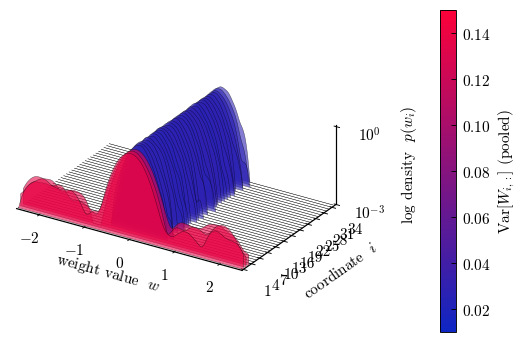

In [4]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look)
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------

def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------

def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")


def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------

def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]


def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a


def load_many_W(model_paths, map_location="cpu"):
    """Return list of W tensors (each d x N_i). All must share same d."""
    W_list = []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if W.ndim != 2:
            raise ValueError(f"{p}: expected W to be 2D, got {tuple(W.shape)}")
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(
                f"All models must share the same number of rows d. "
                f"Got {d_ref} and {W.shape[0]} for {p}."
            )
        W_list.append(W.detach().cpu())
    return W_list  # [d x N_i], same d, variable N_i okay

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------

def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^	op$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 6.4),
):
    """Average Gram (WW^T) across models and draw a boxed heatmap.

    New: pass `figsize=(width, height)` to control figure size.
    """
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------

def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pw_NN.svg",
    # New knobs for making it FLATTER
    figsize=(10.5, 6.2),     # figure size (w, h)
    z_scale=1.0,             # compress vertical scale: e.g. 0.3 for much flatter
    box_aspect=None,         # e.g. (1, 1, 0.25) to squash z vs x/y
    ortho=True,              # use orthographic projection to reduce perspective
    # New: explicit log tick exponents (unscaled). Example: (0,3) -> show 10^0 and 10^3
    z_log_ticks=None,
):
    """3D ridgeline of average per-row densities across models.

    To make the plot flatter:
      - Lower `z_scale` (try 0.2–0.5).
      - Pass a smaller height in `figsize` (e.g., (10.5, 3.6)).
      - Set `box_aspect=(1, 1, 0.25)` (requires Matplotlib ≥3.3).
      - Reduce `y_step` to squeeze rows closer together.
      - Keep `ortho=True` to reduce perspective exaggeration.

    Ticks:
      - If `z_log=True` and `z_log_ticks` is provided (e.g., `(0, 3)`), the Z axis
        will only show those powers of 10.
    """
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- vertical compression (NEW) ----------
    z_scale = float(z_scale) if np.isfinite(z_scale) else 1.0
    dens_plot_scaled = base_z + (dens_plot - base_z) * z_scale

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot_scaled, v in zip(dens_plot_scaled, variances):
        poly = list(zip(grid, di_plot_scaled)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')

    # Orthographic projection reduces perspective exaggeration (flatter look)
    try:
        ax.set_proj_type('ortho' if ortho else 'persp')
    except Exception:
        pass

    ys = np.arange(len(rows)) * y_step
    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot_scaled)) if dens_plot_scaled.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        if z_log_ticks is not None and len(z_log_ticks) > 0:
            # Map requested exponents (unscaled) to scaled Z positions
            tick_positions = [base_z + (float(E) - base_z) * max(z_scale, 1e-12) for E in z_log_ticks]
            ax.set_zticks(tick_positions)
            ax.set_zticklabels([rf"$10^{{{int(E)}}}$" for E in z_log_ticks])
        else:
            # Default: integer ticks with formatter that accounts for scaling
            ax.zaxis.set_major_locator(MaxNLocator(integer=True))
            def _log_tick_formatter(v, pos):
                inv = base_z + (v - base_z) / max(z_scale, 1e-12)  # inverse of scaling
                return rf"$10^{{{int(round(inv))}}}$"
            ax.zaxis.set_major_formatter(FuncFormatter(_log_tick_formatter))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    # Optional: force a flatter 3D box aspect (requires Matplotlib ≥ 3.3)
    if box_aspect is not None:
        try:
            ax.set_box_aspect(box_aspect)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide an explicit list of model files you want to average over:
MODEL_FILES = [
    "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/final_model_P_10000_d_35_k_3_exp_0_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
    "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/final_model_P_10000_d_35_k_3_exp_1_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
    "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/final_model_P_10000_d_35_k_3_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    # put your paths here (absolute or relative)
    # e.g. "results/.../final_model_*.pt"
]
if not MODEL_FILES:
    # fallback: grab 10 newest final_model_*.pt from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "final_model_*.pt")),
        key=os.path.getmtime
    )
    MODEL_FILES = all_candidates[-10:]  # last 10

print("Loading N models:", len(MODEL_FILES))
W_list = load_many_W(MODEL_FILES, map_location="cpu")

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.01
HEAT_VMAX = 0.15

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.15

# 1) Average WW^T heatmap across models (now with figsize)


# 2) Multi-model ridgeline: average p(w_i) across models
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-2.5, 2.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,            # or e.g. weights ∝ N_i
    y_step=0.65,                   # << rows closer together
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pw_NNsig.svg",
    # NEW knobs to make it *much flatter*:
    figsize=(10.5, 3.8),   # << shorter figure height
    z_scale=0.30,          # << compress vertical scale strongly
    box_aspect=(1.5, 1, 0.5),  # << squash z relative to x/y
    ortho=True,
    # NEW: only show two Z ticks at 10^0 and 10^3
    z_log_ticks=(-3, 0),
)
